# Weather Condition Analysis & Linear Regression Model

## 1. Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## 2. Data Loading

In [25]:
weather = pd.read_csv('../data/Summary of Weather.csv', low_memory=False)
print(f'Weather shape: {weather.shape}')
weather.head()

Weather shape: (119040, 31)


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
station = pd.read_csv('../data/Weather Station Locations.csv')
print(f'Station shape: {station.shape}')
station.head()

Station shape: (161, 8)


,WBAN,NAME,STATE/COUNTRY ID,LAT,LON,ELEV,Latitude,Longitude
0,33013,AIN EL,AL,3623N,00637E,611,36.383333,6.650000
1,33031,LA SENIA,AL,3537N,00037E,88,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,3643N,00314E,23,36.716667,3.216667
3,33044,TELERGMA,AL,3607N,00621E,754,36.116667,6.416667
4,12001,TINDOUF,AL,2741N,00809W,443,27.683333,-8.083333


## 3. Exploratory  Data Analysis

### Stations

In [27]:
station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   WBAN              161 non-null    int64  
 1   NAME              161 non-null    object 
 2   STATE/COUNTRY ID  161 non-null    object 
 3   LAT               161 non-null    object 
 4   LON               161 non-null    object 
 5   ELEV              161 non-null    int64  
 6   Latitude          161 non-null    float64
 7   Longitude         161 non-null    float64
dtypes: float64(2), int64(2), object(4)
memory usage: 10.2+ KB


In [28]:
station.describe()

,WBAN,ELEV,Latitude,Longitude
count,161.000000,161.000000,161.000000,161.000000
mean,33421.440994,439.850932,20.347205,8.364182
std,20826.534394,1745.422339,21.042992,87.420419
min,10001.000000,1.000000,-27.600000,-175.000000
25%,13601.000000,9.000000,8.233333,-60.850000
50%,32906.000000,27.000000,22.333333,9.083333
75%,34150.000000,98.000000,36.116667,67.250000
max,82506.000000,9999.000000,67.016667,177.366667


In [29]:
print(f'Total number of stations: {station.shape[0]}')
print('\nCountry / State distribution:')
print(station['STATE/COUNTRY ID'].value_counts())
print('\nMissing values:')
print(station.isnull().sum())

Total number of stations: 161

Country / State distribution:
STATE/COUNTRY ID
IY    14
IN    11
AU     9
PM     8
FR     7
      ..
SP     1
TI     1
TO     1
TU     1
UK     1
Name: count, Length: 64, dtype: int64

Missing values:
WBAN                0
NAME                0
STATE/COUNTRY ID    0
LAT                 0
LON                 0
ELEV                0
Latitude            0
Longitude           0
dtype: int64


### Weather 

In [30]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  object 
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877 non-

In [31]:
weather.describe()

,STA,WindGustSpd,MaxTemp,MinTemp,MeanTemp,YR,MO,DA,DR,SPD,...,FT,FB,FTI,ITH,PGT,SD3,RHX,RHN,RVG,WTE
count,119040.000000,532.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,533.000000,532.000000,...,0.0,0.0,0.0,0.0,525.000000,0.0,0.0,0.0,0.0,0.0
mean,29659.435795,37.774534,27.045111,17.789511,22.411631,43.805284,6.726016,15.797530,26.998124,20.396617,...,NaN,NaN,NaN,NaN,12.085333,NaN,NaN,NaN,NaN,NaN
std,20953.209402,10.297808,8.717817,8.334572,8.297982,1.136718,3.425561,8.794541,15.221732,5.560371,...,NaN,NaN,NaN,NaN,5.731328,NaN,NaN,NaN,NaN,NaN
min,10001.000000,18.520000,-33.333333,-38.333333,-35.555556,40.000000,1.000000,1.000000,2.000000,10.000000,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,11801.000000,29.632000,25.555556,15.000000,20.555556,43.000000,4.000000,8.000000,11.000000,16.000000,...,NaN,NaN,NaN,NaN,8.500000,NaN,NaN,NaN,NaN,NaN
50%,22508.000000,37.040000,29.444444,21.111111,25.555556,44.000000,7.000000,16.000000,32.000000,20.000000,...,NaN,NaN,NaN,NaN,11.600000,NaN,NaN,NaN,NaN,NaN
75%,33501.000000,43.059000,31.666667,23.333333,27.222222,45.000000,10.000000,23.000000,34.000000,23.250000,...,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,NaN
max,82506.000000,75.932000,50.000000,34.444444,40.000000,45.000000,12.000000,31.000000,78.000000,41.000000,...,NaN,NaN,NaN,NaN,23.900000,NaN,NaN,NaN,NaN,NaN


In [32]:
missing = weather.isnull().sum()
missing_pct = (missing / len(weather) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Rate (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Rate (%)', ascending=False)
missing_df

,Missing Count,Missing Rate (%)
RHN,119040,100.00
RHX,119040,100.00
RVG,119040,100.00
FT,119040,100.00
FTI,119040,100.00
FB,119040,100.00
WTE,119040,100.00
ITH,119040,100.00
SD3,119040,100.00
PGT,118515,99.56


## 4. Visualization
### Stations - Bar Chart: stations by country

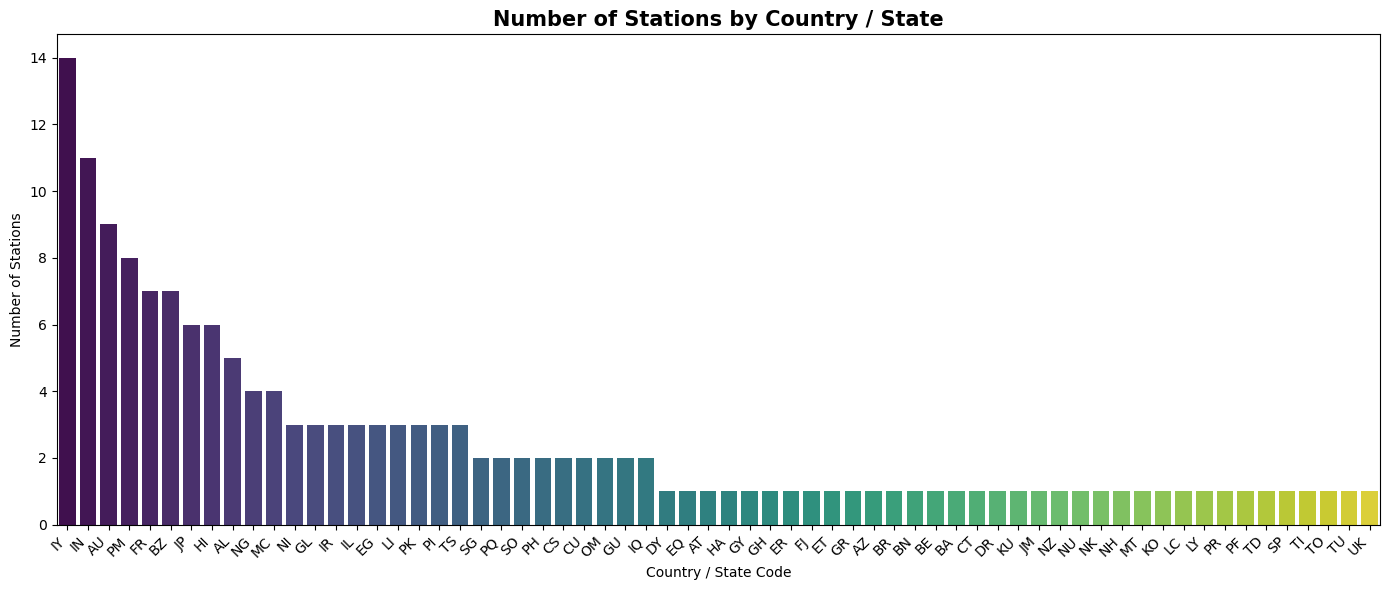

In [42]:
country_counts = station['STATE/COUNTRY ID'].value_counts()

plt.figure(figsize=(14, 6))
ax = sns.barplot(x=country_counts.index, y=country_counts.values, hue=country_counts.index, palette='viridis', legend=False)
ax.set_title('Number of Stations by Country / State', fontsize=15, fontweight='bold')
ax.set_xlabel('Country / State Code')
ax.set_ylabel('Number of Stations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


###  Histogram: MaxTemp, MinTemp, MeanTemp distribution

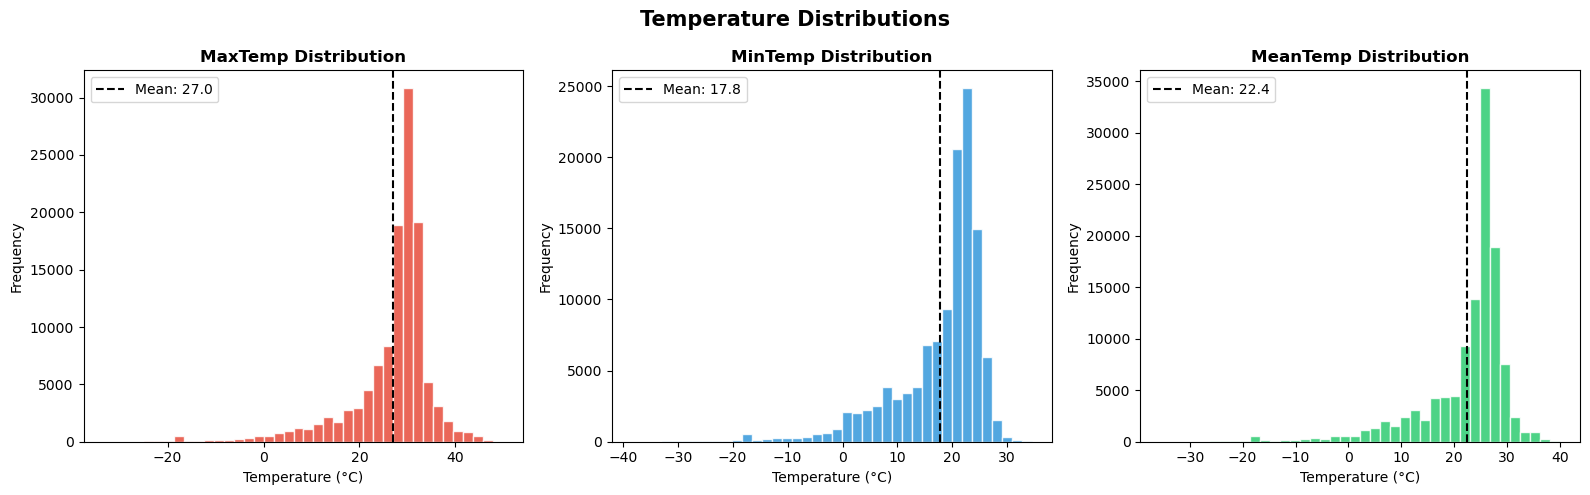

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cols   = ['MaxTemp', 'MinTemp', 'MeanTemp']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, col, color in zip(axes, cols, colors):
    data = weather[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col + ' Distribution', fontweight='bold')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label='Mean: ' + str(round(data.mean(), 1)))
    ax.legend()

plt.suptitle('Temperature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### MaxTemp, MinTemp, MeanTemp Boxplot

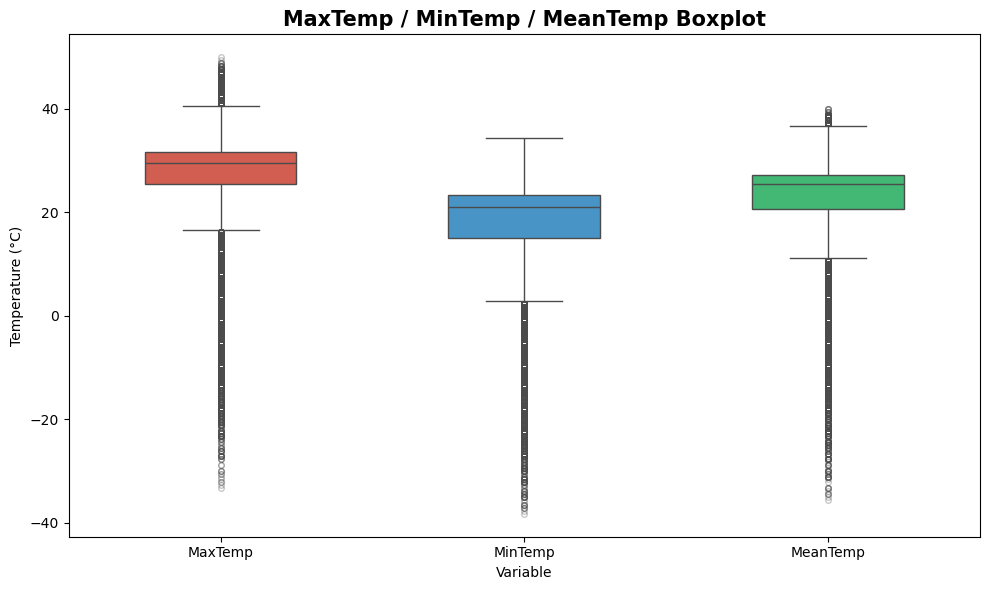

In [35]:
temp_data = weather[['MaxTemp', 'MinTemp', 'MeanTemp']].dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=temp_data,
    palette=['#e74c3c', '#3498db', '#2ecc71'],
    width=0.5,
    flierprops=dict(marker='o', markersize=4, alpha=0.3)
)
plt.title('MaxTemp / MinTemp / MeanTemp Boxplot', fontsize=15, fontweight='bold')
plt.ylabel('Temperature (°C)')
plt.xlabel('Variable')
plt.tight_layout()
plt.show()


### Correlation Heatmap

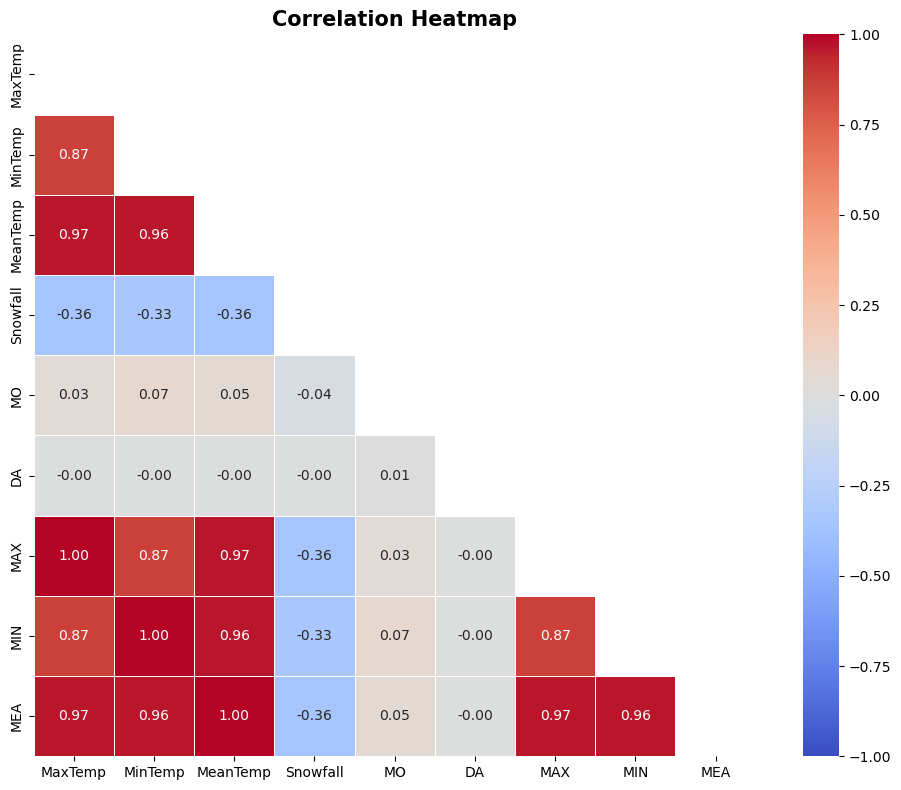

In [36]:
numeric_cols = ['MaxTemp', 'MinTemp', 'MeanTemp', 'Snowfall', 'MO', 'DA', 'MAX', 'MIN', 'MEA']
corr_data    = weather[numeric_cols].apply(pd.to_numeric, errors='coerce').dropna()
corr_matrix  = corr_data.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True
)
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### MaxTemp vs MeanTemp Scatter Plot

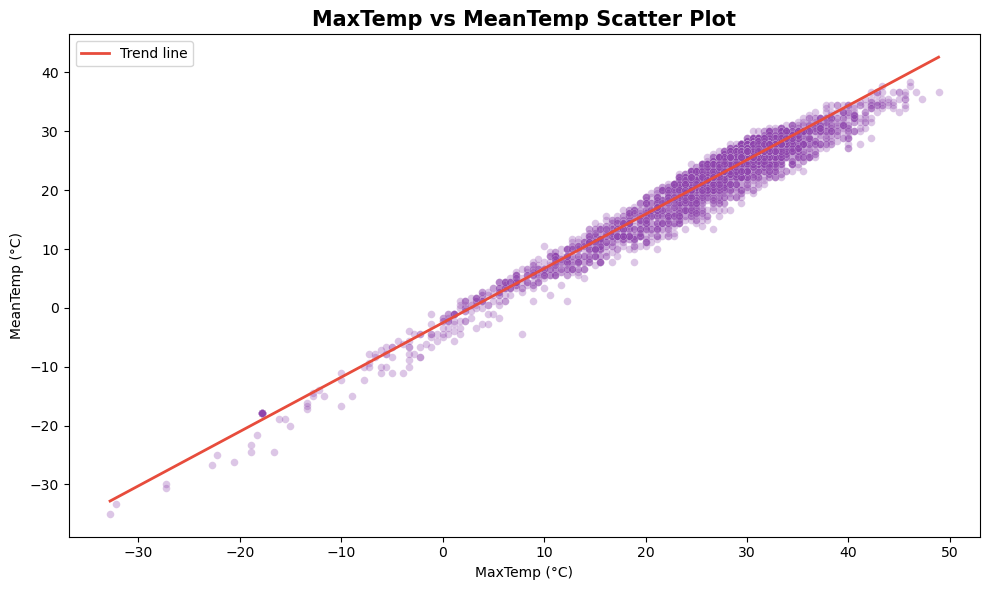

In [37]:
sample = weather[['MaxTemp', 'MeanTemp']].dropna().sample(n=5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['MaxTemp'], sample['MeanTemp'],
            alpha=0.3, color='#8e44ad', edgecolors='white', linewidths=0.2, s=30)

z = np.polyfit(sample['MaxTemp'], sample['MeanTemp'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['MaxTemp'].min(), sample['MaxTemp'].max(), 100)
plt.plot(x_line, p(x_line), color='#e74c3c', linewidth=2, label='Trend line')

plt.title('MaxTemp vs MeanTemp Scatter Plot', fontsize=15, fontweight='bold')
plt.xlabel('MaxTemp (°C)')
plt.ylabel('MeanTemp (°C)')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Data Cleaning

In [38]:
weather['Precip']   = weather['Precip'].replace('T', '0.0')
weather['Precip']   = pd.to_numeric(weather['Precip'], errors='coerce')
weather['Snowfall'] = weather['Snowfall'].replace('T', '0.0')
weather['Snowfall'] = pd.to_numeric(weather['Snowfall'], errors='coerce')

print('Precip dtype  :', weather['Precip'].dtype)
print('Snowfall dtype:', weather['Snowfall'].dtype)

# Drop rows with missing values in model columns
model_cols    = ['MaxTemp', 'MinTemp', 'MeanTemp']
weather_clean = weather[model_cols].dropna()

print(f'\nBefore cleaning : {weather.shape[0]} rows')
print(f'After cleaning  : {weather_clean.shape[0]} rows')
weather_clean.describe()


Precip dtype  : float64
Snowfall dtype: float64

Before cleaning : 119040 rows
After cleaning  : 119040 rows


,MaxTemp,MinTemp,MeanTemp
count,119040.000000,119040.000000,119040.000000
mean,27.045111,17.789511,22.411631
std,8.717817,8.334572,8.297982
min,-33.333333,-38.333333,-35.555556
25%,25.555556,15.000000,20.555556
50%,29.444444,21.111111,25.555556
75%,31.666667,23.333333,27.222222
max,50.000000,34.444444,40.000000


## 6. Model - Linear Regression

In [ ]:
# X: features | y: target
X = weather_clean[['MaxTemp', 'MinTemp']]
y = weather_clean['MeanTemp']

# Train / Test split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set : {X_train.shape[0]} rows')
print(f'Test set     : {X_test.shape[0]} rows')

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

print('\nModel trained.')
print('Coefficients:')
for col, coef in zip(X.columns, model.coef_):
    print(f'  {col}: {coef:.4f}')
print(f'Intercept: {model.intercept_:.4f}')


Training set : 95232 rows
Test set     : 23808 rows

Model trained.
Coefficients:
  MaxTemp: 0.5059
  MinTemp: 0.4964
Intercept: -0.1024


## 7. Evaluation

In [40]:
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('=' * 45)
print('       Model Evaluation Metrics')
print('=' * 45)
print(f'  R²   (R-squared)          : {r2:.4f}')
print(f'  MAE  (Mean Absolute Error) : {mae:.4f} °C')
print(f'  RMSE (Root Mean Sq. Error) : {rmse:.4f} °C')
print('=' * 45)


       Model Evaluation Metrics
  R²   (R-squared)          : 0.9971
  MAE  (Mean Absolute Error) : 0.1644 °C
  RMSE (Root Mean Sq. Error) : 0.4401 °C


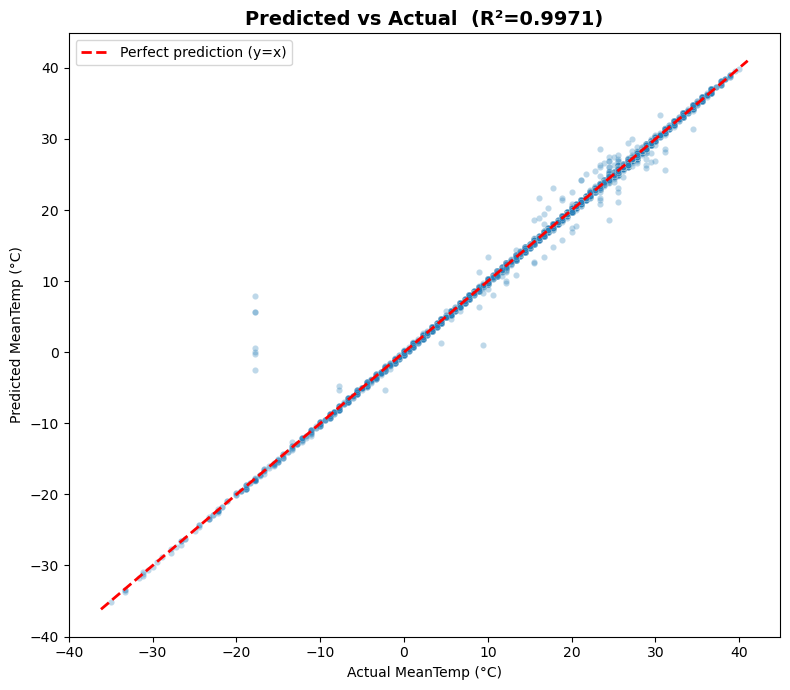

In [41]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred, alpha=0.3, color='#2980b9',
            edgecolors='white', linewidths=0.2, s=20)

lims = [min(y_test.min(), y_pred.min()) - 1,
        max(y_test.max(), y_pred.max()) + 1]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction (y=x)')

plt.title(f'Predicted vs Actual  (R²={r2:.4f})', fontsize=14, fontweight='bold')
plt.xlabel('Actual MeanTemp (°C)')
plt.ylabel('Predicted MeanTemp (°C)')
plt.legend()
plt.tight_layout()
plt.show()
